In [5]:
import numpy as np

import torch
import torch.nn as nn 
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import helper_utils

In [7]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Useing device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

print(f'{device}')

cuda


In [4]:
data_path = "./data"

In [5]:
train_dataset_without_transform = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True
)

100.0%
100.0%
100.0%
100.0%


In [8]:
image_pil, label = train_dataset_without_transform[0]
print(f"Image type:        {type(image_pil)}")
# Since `image_pil` is a PIL Image object, its dimensions are accessed using the .size attribute.
print(f"Image Dimensions:  {image_pil.size}")
print(f"Label Type:        {type(label)}")
print(f"Label value:       {label}")

Image type:        <class 'PIL.Image.Image'>
Image Dimensions:  (28, 28)
Label Type:        <class 'int'>
Label value:       5


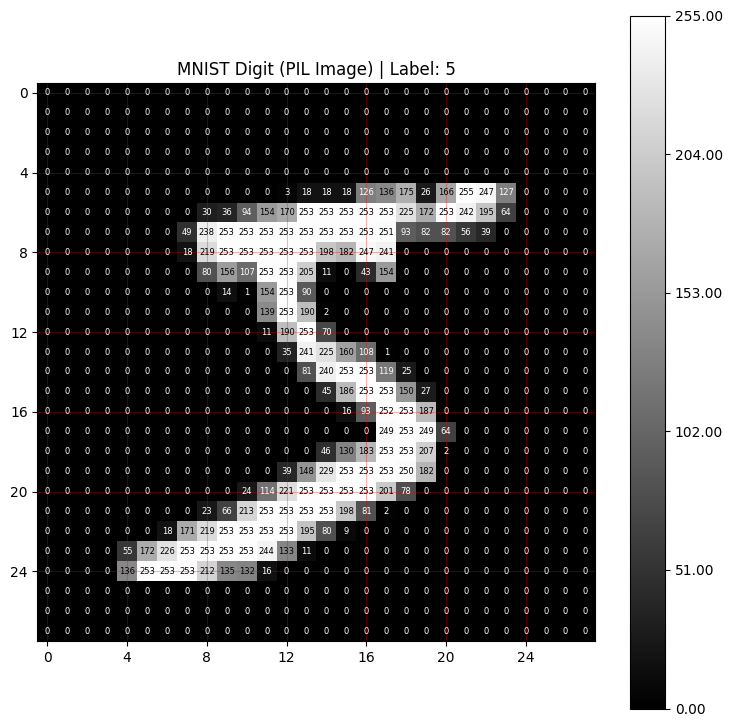

In [9]:
# Visualize the sample image and its corresponding label
helper_utils.display_image(image_pil, label, "MNIST Digit (PIL Image)", show_values=True)

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081)) # MNIST data mean and std
])

In [13]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=transform
)

In [23]:
# Access the first item again
image_tensor, label = train_dataset[0]

print(f"Image Type:                   {type(image_tensor)}")
# Since the `image` is now a PyTorch Tensor, its dimensions are accessed using the .shape attribute.
print(f"Image Shape After Transform:  {image_tensor.shape}")
print(f"Label Type:                   {type(label)}")
print(f"Label value:                  {label}")
print(f'\nTotal Dataset: {len(train_dataset)}')

Image Type:                   <class 'torch.Tensor'>
Image Shape After Transform:  torch.Size([1, 28, 28])
Label Type:                   <class 'int'>
Label value:                  5

Total Dataset: 60000


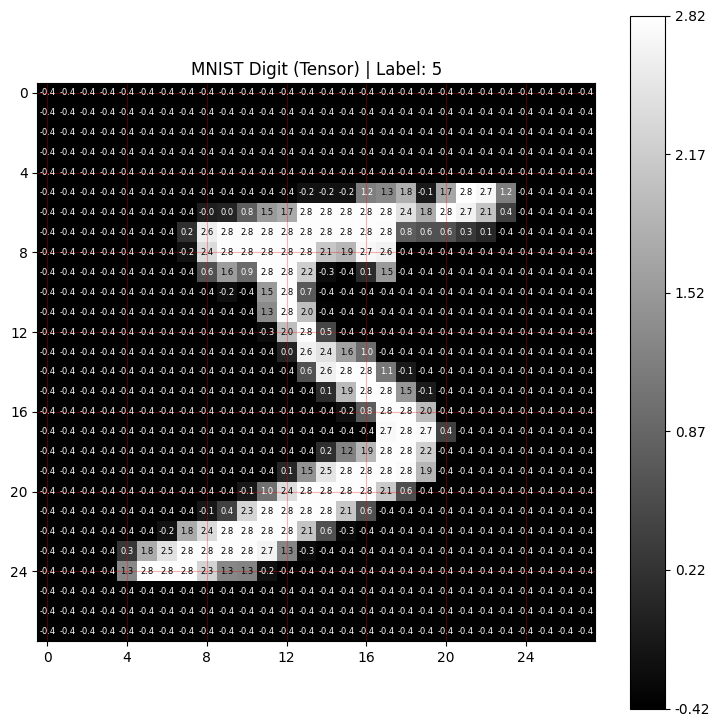

In [15]:
# Visualize the transformed image and its label
helper_utils.display_image(image_tensor, label, "MNIST Digit (Tensor)", show_values=True)

In [16]:
test_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=False,
    download=True,
    transform=transform
)

In [30]:
# Data Loader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Length of Train Loader: {len(train_loader)} \nLenght of Test Loader: {len(test_loader)}")

Length of Train Loader: 938 
Lenght of Test Loader: 157


In [41]:
# Model Definition
class SimpleMNISTDNN(nn.Module):
    def __init__(self, *args, **kwargs):
        super(SimpleMNISTDNN, self).__init__(*args, **kwargs)

        self.flatten = nn.Flatten()  # Initializes a layer to flatten the input tensor. 28x28 input image to a 784-dimensional vector.
        self.layers = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        x = self.layers(x)
        return x

In [42]:
# Model Initialization
model = SimpleMNISTDNN()

loss_function = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [43]:
# Training

def train_epoch(model, loss_function, optimizer, train_loader, device):
    model = model.to(device)
    model.train()
    epoch_loss = 0.0
    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0
    total_batches = len(train_loader)

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, targets)
        loss.backward()
        optimizer.step()

        # accumulate the loss
        loss_value = loss.item()
        epoch_loss += loss_value
        running_loss += loss_value

        # accuracy matrics
        _, predicted_indices = outputs.max(1)
        batch_size = targets.size(0)
        total_predictions += batch_size
        num_correct_in_batch = predicted_indices.eq(targets).sum().item()
        num_correct_predictions += num_correct_in_batch

        # Check if it's time to print a progress update
        if (batch_idx + 1) % 134 == 0 or (batch_idx + 1) == total_batches:
            # Calculate average loss and accuracy for the current interval
            avg_running_loss = running_loss / 134
            accuracy = 100. * num_correct_predictions / total_predictions
            
            # Print the progress update
            print(f'\tStep {batch_idx + 1}/{total_batches} - Loss: {avg_running_loss:.3f} | Acc: {accuracy:.2f}%')
            
            # Reset the trackers for the next reporting interval
            running_loss = 0.0
            num_correct_predictions = 0
            total_predictions = 0

    # Calculate the average loss for the entire epoch
    avg_epoch_loss = epoch_loss / total_batches
    
    # Return the trained model and the average epoch loss
    return model, avg_epoch_loss

In [44]:
# Evaluation Model
def evaluate(model, test_loader, device):
    model.eval()

    num_correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            _, predicted_indices = outputs.max(1)
            
            batch_size = targets.size(0)
            total_predictions += batch_size

            correct_prediction = predicted_indices.eq(targets).sum().item()
            num_correct_predictions += correct_prediction

    # Calculates the overall accuracy as a percentage.
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100
    # Prints the calculated accuracy to the console.
    print((f'\tAccuracy - {accuracy_percentage:.2f}%'))
    
    return accuracy_percentage

In [45]:
# Run the Training loop
number_of_epochs = 10

train_loss = []
test_acc = []

# Begin the training and evaluation process
for epoch in range(number_of_epochs):
    print(f'\n[Training] Epoch {epoch+1}:')
    # Call the training function to train the model for one epoch
    trained_model, loss = train_epoch(model, loss_function, optimizer, train_loader, device)
    # Store the average training loss for the epoch
    train_loss.append(loss)
    
    print(f'[Testing] Epoch {epoch+1}:')
    # Call the evaluation function to measure performance on the test set
    accuracy = evaluate(trained_model, test_loader, device)
    # Store the test accuracy for the epoch
    test_acc.append(accuracy)


[Training] Epoch 1:
	Step 134/938 - Loss: 0.562 | Acc: 83.50%
	Step 268/938 - Loss: 0.287 | Acc: 91.90%
	Step 402/938 - Loss: 0.242 | Acc: 92.98%
	Step 536/938 - Loss: 0.209 | Acc: 93.67%
	Step 670/938 - Loss: 0.191 | Acc: 94.55%
	Step 804/938 - Loss: 0.168 | Acc: 94.97%
	Step 938/938 - Loss: 0.148 | Acc: 95.82%
[Testing] Epoch 1:
	Accuracy - 95.74%

[Training] Epoch 2:
	Step 134/938 - Loss: 0.124 | Acc: 96.25%
	Step 268/938 - Loss: 0.124 | Acc: 96.25%
	Step 402/938 - Loss: 0.111 | Acc: 96.62%
	Step 536/938 - Loss: 0.119 | Acc: 96.51%
	Step 670/938 - Loss: 0.105 | Acc: 96.62%
	Step 804/938 - Loss: 0.112 | Acc: 96.67%
	Step 938/938 - Loss: 0.091 | Acc: 97.06%
[Testing] Epoch 2:
	Accuracy - 96.71%

[Training] Epoch 3:
	Step 134/938 - Loss: 0.076 | Acc: 97.60%
	Step 268/938 - Loss: 0.081 | Acc: 97.57%
	Step 402/938 - Loss: 0.082 | Acc: 97.50%
	Step 536/938 - Loss: 0.084 | Acc: 97.49%
	Step 670/938 - Loss: 0.071 | Acc: 97.60%
	Step 804/938 - Loss: 0.084 | Acc: 97.35%
	Step 938/938 - Loss:

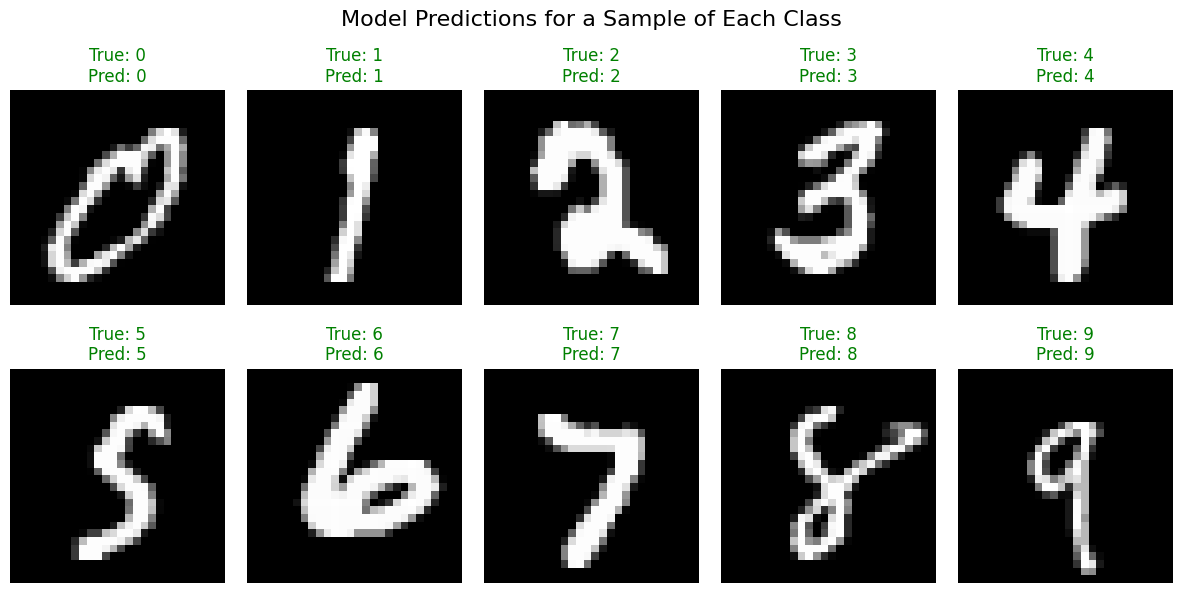

In [46]:
# Visualize model predictions on a random sample of test images
helper_utils.display_predictions(trained_model, test_loader, device)

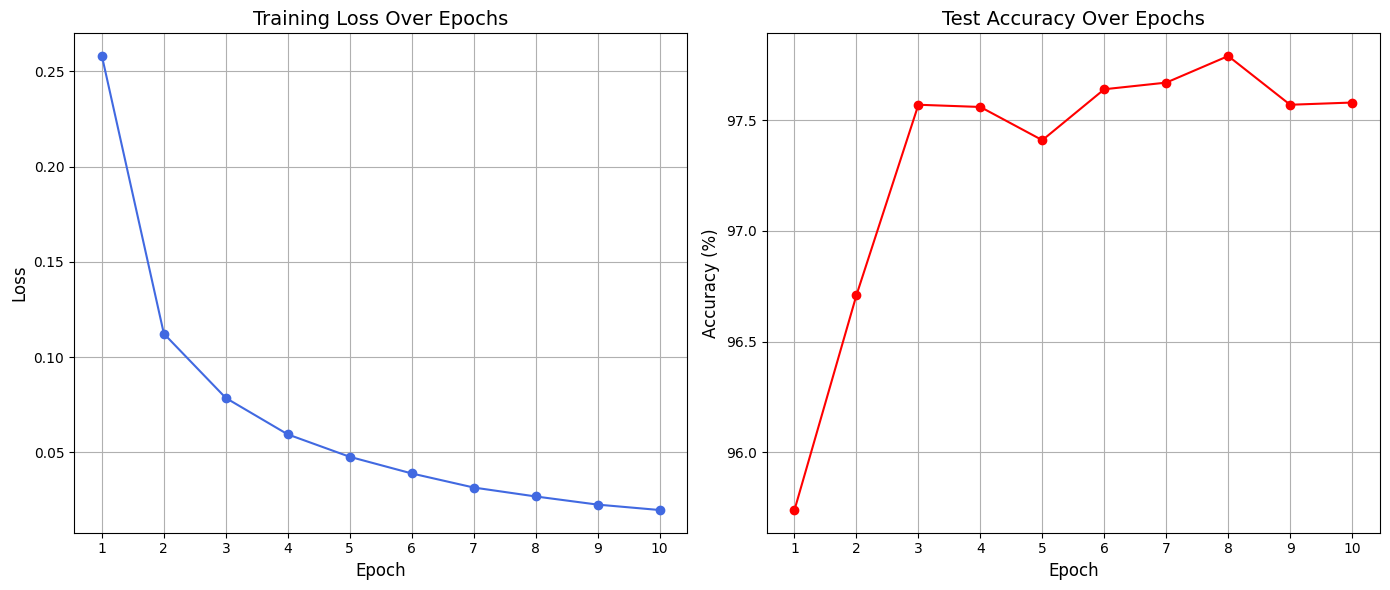

In [47]:
# Plot the training loss and test accuracy curves over all epochs
helper_utils.plot_metrics(train_loss, test_acc)